In [30]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.cluster import KMeans

In [31]:
df=pd.read_csv("corpus_zola_paquets_lemm.csv")

In [32]:
df.head()

,nom_fichier,id_paquet,phrases_paquet,phrases_lemm
0,1893_20_Le_docteur_Pascal._clean.txt,0,Dans la chaleur de l’ardente après-midi de jui...,chaleur ardent après-midi juillet salle volet ...
1,1893_20_Le_docteur_Pascal._clean.txt,1,"Mais il dut prendre une chaise, la planche du ...",chaise planche haut haut grand taille planche ...
2,1893_20_Le_docteur_Pascal._clean.txt,2,"Oh! Monsieur, la religion n’a jamais fait de m...",monsieur religion mal idée sûr silence diverge...
3,1893_20_Le_docteur_Pascal._clean.txt,3,"De face, dans son visage séché, ses yeux garda...",face visage oeil flamme joli sourir grand-mère...
4,1893_20_Le_docteur_Pascal._clean.txt,4,s’écria la jeune fille. Mais elle était lancée...,jeune fille bon femme fond faubourg pile mort ...


In [33]:
vectorizer = TfidfVectorizer(
    min_df=3,
    max_df=0.8
)
X = vectorizer.fit_transform(df["phrases_lemm"])

In [34]:
kmeans= KMeans(n_clusters=28, 
               random_state=42,
               n_init=10)

df["cluster"] = kmeans.fit_predict(X) +1 

In [35]:
df.head()

,nom_fichier,id_paquet,phrases_paquet,phrases_lemm,cluster
0,1893_20_Le_docteur_Pascal._clean.txt,0,Dans la chaleur de l’ardente après-midi de jui...,chaleur ardent après-midi juillet salle volet ...,24
1,1893_20_Le_docteur_Pascal._clean.txt,1,"Mais il dut prendre une chaise, la planche du ...",chaise planche haut haut grand taille planche ...,7
2,1893_20_Le_docteur_Pascal._clean.txt,2,"Oh! Monsieur, la religion n’a jamais fait de m...",monsieur religion mal idée sûr silence diverge...,4
3,1893_20_Le_docteur_Pascal._clean.txt,3,"De face, dans son visage séché, ses yeux garda...",face visage oeil flamme joli sourir grand-mère...,26
4,1893_20_Le_docteur_Pascal._clean.txt,4,s’écria la jeune fille. Mais elle était lancée...,jeune fille bon femme fond faubourg pile mort ...,5


In [40]:
terms = vectorizer.get_feature_names_out()
centres = kmeans.cluster_centers_

for i, centre in enumerate(centres):
    top_indices = centre.argsort()[::-1][:10]
    mots = [terms[j] for j in top_indices]
    print(f"Cluster {i+1} :", " | ".join(mots))

Cluster 1 : million | bourse | cours | action | franc | banque | universelle | argent | affaire | titre
Cluster 2 : travail | vie | peuple | enfant | terre | bonheur | petit | monde | homme | œuvre
Cluster 3 : train | fosse | machine | heure | voie | homme | berline | puits | coup | mineur
Cluster 4 : enfant | mère | fille | femme | petit | vie | cœur | père | jour | bon
Cluster 5 : homme | frère | femme | jeune | petit | affaire | main | porte | monsieur | fine
Cluster 6 : franc | argent | monsieur | fille | femme | bon | père | jour | petit | fortune
Cluster 7 : docteur | monsieur | médecin | enfant | mère | petit | malade | oeil | lit | heure
Cluster 8 : jeune | femme | amant | amour | cœur | pensée | vie | homme | jour | voix
Cluster 9 : saint | église | abbé | autel | monseigneur | prêtre | chapelle | vierge | blanc | cierge
Cluster 10 : coupeau | maman | boutique | zingueur | rue | petit | blanchisseur | jour | verre | vin
Cluster 11 : chambre | lit | heure | main | oeil | petit 

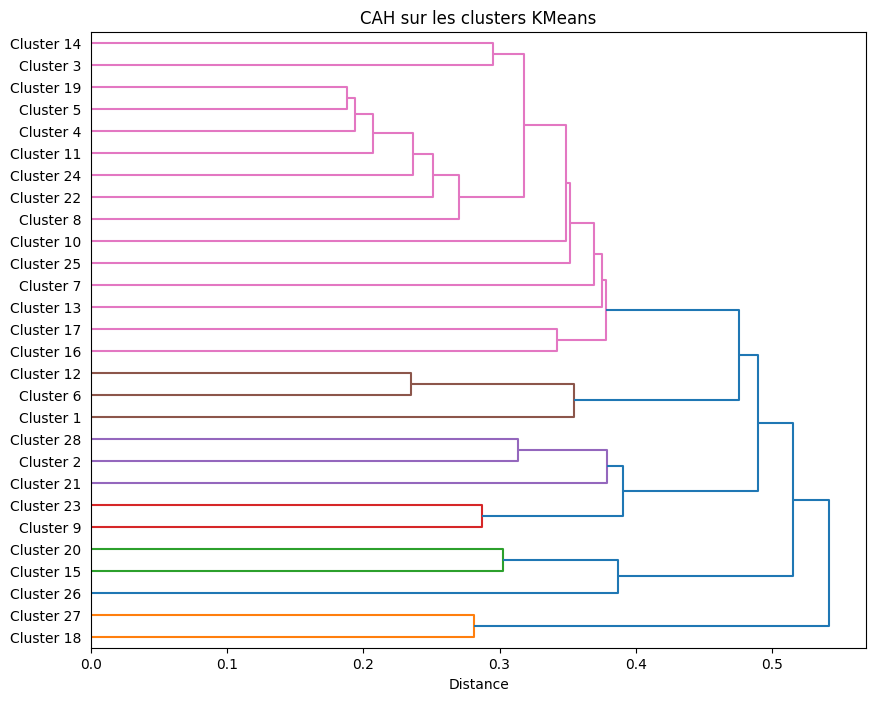

In [39]:
centres = kmeans.cluster_centers_
Z = linkage(centres, method="ward")

plt.figure(figsize=(10, 8))
dendrogram(
    Z,
    labels=[f"Cluster {i+1}" for i in range(kmeans.n_clusters)],
    orientation="right"
)

plt.title("CAH sur les clusters KMeans")
plt.xlabel("Distance")
plt.show()

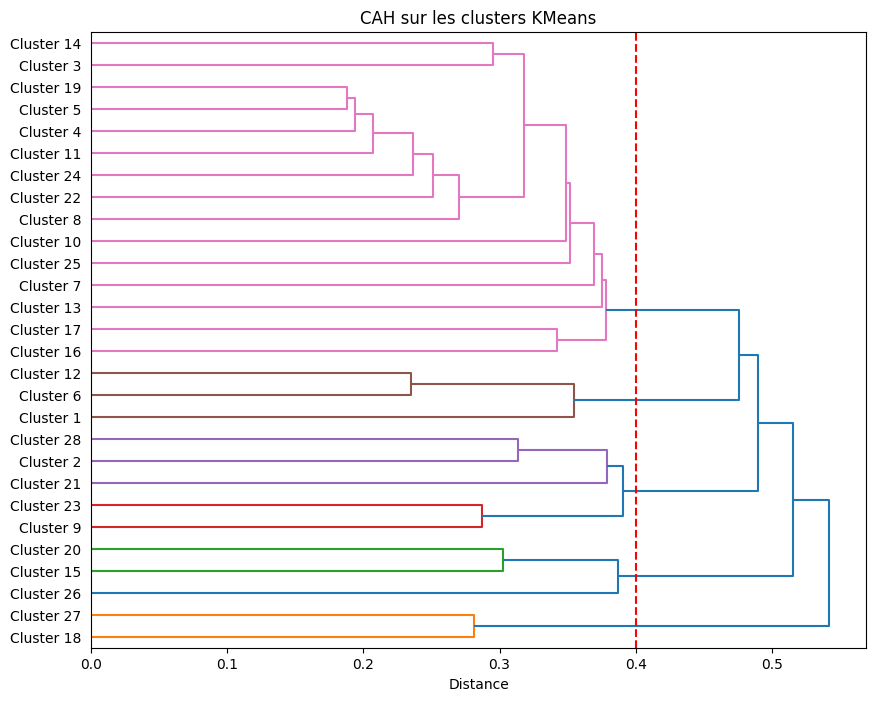

In [41]:
plt.figure(figsize=(10, 8))

dendrogram(
    Z,
    labels=[f"Cluster {i+1}" for i in range(kmeans.n_clusters)],
    orientation="right"
)

plt.axvline(x=0.40, color="red", linestyle="--")

plt.title("CAH sur les clusters KMeans")
plt.xlabel("Distance")
plt.show()

In [42]:
from scipy.cluster.hierarchy import fcluster

groupes_cah = fcluster(Z, t=0.40, criterion="distance")
groupes_cah

array([4, 3, 5, 5, 5, 4, 5, 5, 3, 5, 5, 4, 5, 5, 2, 5, 5, 1, 5, 2, 3, 5,
       3, 5, 5, 2, 1, 3], dtype=int32)

In [44]:
from scipy.cluster.hierarchy import fcluster

groupes_cah = fcluster(Z, t=5, criterion="maxclust")
groupes_cah

array([4, 3, 5, 5, 5, 4, 5, 5, 3, 5, 5, 4, 5, 5, 2, 5, 5, 1, 5, 2, 3, 5,
       3, 5, 5, 2, 1, 3], dtype=int32)

In [45]:
for cluster_kmeans, groupe in enumerate(groupes_cah, start=1):
    print(f"Cluster {cluster_kmeans} ==> Groupe CAH {groupe}")

Cluster 1 ==> Groupe CAH 4
Cluster 2 ==> Groupe CAH 3
Cluster 3 ==> Groupe CAH 5
Cluster 4 ==> Groupe CAH 5
Cluster 5 ==> Groupe CAH 5
Cluster 6 ==> Groupe CAH 4
Cluster 7 ==> Groupe CAH 5
Cluster 8 ==> Groupe CAH 5
Cluster 9 ==> Groupe CAH 3
Cluster 10 ==> Groupe CAH 5
Cluster 11 ==> Groupe CAH 5
Cluster 12 ==> Groupe CAH 4
Cluster 13 ==> Groupe CAH 5
Cluster 14 ==> Groupe CAH 5
Cluster 15 ==> Groupe CAH 2
Cluster 16 ==> Groupe CAH 5
Cluster 17 ==> Groupe CAH 5
Cluster 18 ==> Groupe CAH 1
Cluster 19 ==> Groupe CAH 5
Cluster 20 ==> Groupe CAH 2
Cluster 21 ==> Groupe CAH 3
Cluster 22 ==> Groupe CAH 5
Cluster 23 ==> Groupe CAH 3
Cluster 24 ==> Groupe CAH 5
Cluster 25 ==> Groupe CAH 5
Cluster 26 ==> Groupe CAH 2
Cluster 27 ==> Groupe CAH 1
Cluster 28 ==> Groupe CAH 3
